# 5장 실습 — 시연 큐레이션

실기에서 모은 시연에는 불량이 섞인다. 조작자가 칸을 헷갈리고, 망설이고, 손이 떨린다. 큐레이션은 그런 시연을 골라내는 일이다.

이 노트북은 3장이 정한 설정(잡음 주입, 종류 층화)으로 좋은 시연 128판을 모으고, 세 종류의 불량 시연 32판을 섞는다. 그리고 큐레이션 지표 넷을 같은 데이터에 걸어 두 가지를 나란히 잰다.

1. **탐지 성능** — 불량을 얼마나 잘 가려내는가 (AUROC)
2. **다운스트림 성적** — 지표가 가려낸 것을 빼고 다시 학습하면 배포 성공률이 얼마인가

두 수가 같은 방향을 가리키는지가 이 장의 질문이다.

끝에서 `data/clean_v1.npz`(골라낸 시연)와 `report/curation.json` 을 남긴다.

실행 시간은 CPU에서 5분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
CFG = {"sigma": .22}
if os.path.exists("data/collect.json"):
    CFG = json.load(open("data/collect.json"))
    print("1부가 남긴 수집 설정을 읽었다")
SIG = CFG.get("sigma") or .22
print(f"잡음 표준편차 {SIG}")

1부가 남긴 수집 설정을 읽었다
잡음 표준편차 0.22


## 불량 시연 세 종류

좋은 시연은 2장의 잡음 주입 경로 그대로다. 불량은 실기의 원격조작에서 흔히 보고되는 세 가지를 흉내 낸다.

| 종류 | 만드는 법 | 실기에서의 모습 |
|---|---|---|
| 좋음 | 전문가 + 실행 잡음, 라벨은 전문가 | — |
| 칸 착오 | 반대 적재함으로 미는 전문가 (관측의 종류 표시는 그대로) | 조작자가 부품 종류를 헷갈림 |
| 망설임 | 명령이 35% 확률로 0, 라벨은 실행 명령 | 조작자가 멈칫거림 |
| 떨림 | 표준편차 0.6의 잡음, 라벨은 실행 명령 | 손떨림, 조작 장치 잡음 |

칸 착오 시연은 제 적재함에 닿지 않으므로 판이 110스텝까지 간다. 망설임도 판이 길어진다. **이 길이 차이가 뒤에서 문제를 일으킨다.**

In [8]:
def servo_to(env, flip):
    """flip=True 면 반대 적재함을 목표로 삼는 전문가"""
    g = env.g.copy()
    if flip:
        for i in range(env.n):
            k = env.k[i]
            g[i] = bin_xy(1 - k) + (env.g[i] - bin_xy(k))
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(g - b)
    e = b - dv * .045 - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


def episodes(mode, count, seed, n=32):
    """판 단위로 모은다 — 관측, 라벨, 결과"""
    rng = np.random.default_rng(seed)
    env = Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        if mode == "칸 착오":
            lab = servo_to(env, True)
            act = lab + rng.normal(0, SIG, lab.shape)
            act = np.clip(act, -1, 1)
        elif mode == "망설임":
            act = servo(env) + rng.normal(0, SIG, (n, 2))
            act[rng.random(n) < .35] = 0.
            act = lab = np.clip(act, -1, 1)
        elif mode == "떨림":
            act = servo(env) + rng.normal(0, .6, (n, 2))
            act = np.clip(act, -1, 1)
            lab = act
        else:
            lab = servo(env)
            act = lab + rng.normal(0, SIG, lab.shape)
            act = np.clip(act, -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        _, dn, sc = env.step(act.astype(np.float32))
        for j, i in enumerate(np.flatnonzero(dn)):
            hit, wrong, steps, k = sc[j]
            O = np.array([a for a, _ in cur[i]], np.float32)
            A = np.array([b for _, b in cur[i]], np.float32)
            out.append(dict(O=O, A=A, succ=hit, wrong=wrong,
                            steps=steps, kind=k, type=mode))
            cur[i] = []
    return out[:count]


TYPES = ["좋음", "칸 착오", "망설임", "떨림"]
COUNT = {"좋음": 128, "칸 착오": 12, "망설임": 10, "떨림": 10}
t0 = time.time()
EPS = []
for j, t in enumerate(TYPES):
    EPS += episodes(t, COUNT[t], seed=j + 1)
TY = np.array([e["type"] for e in EPS])
BAD = TY != "좋음"
print(f"{len(EPS)}판 수집 ({time.time() - t0:.0f}s)\n")
print(pad("종류", 10) + pad("판", 5, True)
      + pad("평균 길이", 11, True) + pad("성공", 7, True)
      + pad("오배출", 8, True))
for t in TYPES:
    E = [e for e in EPS if e["type"] == t]
    print(pad(t, 10) + pad(len(E), 5, True)
          + pad(f"{np.mean([e['steps'] for e in E]):.1f}", 11, True)
          + pad(f"{np.mean([e['succ'] for e in E]):.2f}", 7, True)
          + pad(f"{np.mean([e['wrong'] for e in E]):.2f}", 8, True))

160판 수집 (3s)

종류         판  평균 길이   성공  오배출
좋음        128       46.3   1.00    0.00
칸 착오      12      110.0   0.00    0.17
망설임       10       61.3   1.00    0.00
떨림         10       46.0   1.00    0.00


## 큐레이션 지표 넷

판마다 점수를 매긴다. 점수가 높을수록 불량으로 본다.

- **길이** — 판의 스텝 수. 가장 단순하고, 문헌에서는 교란 변수로 경고받는 지표다
- **매끄러움** — 라벨의 스텝 사이 변화량 평균. 떨림을 겨냥한다
- **자기 손실** — 모든 시연으로 행동 복제를 학습한 뒤, 판마다 모델의 예측과 라벨의 차이. 「모델과 맞지 않는 판」을 찾는다
- **이웃 불일치** — 다른 판의 가까운 상태 10개가 낸 라벨의 평균과 이 판의 라벨의 차이. 「같은 상황에서 남과 다르게 한 판」을 찾는다

탐지 성능은 AUROC 로 잰다. 불량 판 하나와 좋은 판 하나를 뽑았을 때 불량 쪽 점수가 더 높을 확률이다. 0.5가 우연이고 1.0이 완벽이다.

In [9]:
def cat(E):
    return (np.concatenate([e["O"] for e in E]),
            np.concatenate([e["A"] for e in E]))


def m_len(E):
    return np.array([len(e["O"]) for e in E], float)


def m_smooth(E):
    return np.array([np.abs(np.diff(e["A"], axis=0)).mean()
                     for e in E])


def m_loss(E, seed=0):
    X, Y = cat(E)
    net = bc(X, Y, seed=seed)
    out = []
    with torch.no_grad():
        for e in E:
            p = net.pi(torch.from_numpy(e["O"])).numpy()
            out.append(((p - e["A"]) ** 2).mean())
    return np.array(out)


def m_knn(E, k=10):
    X, Y = cat(E)
    ep = np.concatenate([np.full(len(e["O"]), i)
                         for i, e in enumerate(E)])
    Xt = torch.from_numpy(X)
    out = np.zeros(len(E))
    for i, e in enumerate(E):
        d = torch.cdist(torch.from_numpy(e["O"]), Xt)
        d[:, torch.from_numpy(ep == i)] = 1e9     # 자기 판은 뺀다
        idx = d.topk(k, largest=False).indices.numpy()
        out[i] = np.abs(Y[idx].mean(1) - e["A"]).mean()
    return out


def auroc(y, s):
    """순위로 계산한 AUROC (동점은 평균 순위)"""
    r = np.argsort(np.argsort(s, kind="stable"), kind="stable") + 1.
    for v in np.unique(s):
        m = s == v
        r[m] = r[m].mean()
    npos, nneg = y.sum(), (~y).sum()
    return (r[y].sum() - npos * (npos + 1) / 2) / (npos * nneg)


METRIC = {"길이": m_len, "매끄러움": m_smooth,
          "자기 손실": m_loss, "이웃 불일치": m_knn}
t0 = time.time()
SCORE = {k: f(EPS) for k, f in METRIC.items()}
print(f"점수 계산 ({time.time() - t0:.0f}s)\n")


def auc_row(score):
    out = [auroc(BAD, score)]
    for t in TYPES[1:]:
        sel = (TY == "좋음") | (TY == t)
        out.append(auroc(TY[sel] == t, score[sel]))
    return out


print(pad("지표", 12) + pad("전체", 8, True)
      + "".join(pad(t, 9, True) for t in TYPES[1:]))
AUC = {}
for k in METRIC:
    AUC[k] = auc_row(SCORE[k])
    cells = [pad(f"{a:.3f}", 8 if i == 0 else 9, True)
             for i, a in enumerate(AUC[k])]
    print(pad(k, 12) + "".join(cells))

점수 계산 (7s)

지표            전체  칸 착오   망설임     떨림
길이           0.832    1.000    0.970    0.494
매끄러움       0.654    0.080    0.996    1.000
자기 손실      0.902    0.738    1.000    1.000
이웃 불일치    0.779    0.410    1.000    1.000


## 길이를 통제한다

길이 지표가 칸 착오를 완벽하게 잡은 것은 칸 착오 판이 모두 110스텝이기 때문이다. 이것은 지표가 똑똑해서가 아니라 **불량과 길이가 같이 움직이는 데이터**이기 때문이다. 다른 과제, 다른 불량에서는 성립하지 않는다.

길이의 영향을 걷어 내려면 모든 판을 앞 40스텝으로 잘라 같은 길이로 맞추고 지표를 다시 계산한다. 40스텝보다 짧은 판은 그대로 둔다.

In [10]:
T_CUT = 40
TR = [dict(e, O=e["O"][:T_CUT], A=e["A"][:T_CUT]) for e in EPS]
t0 = time.time()
TRS = {k: f(TR) for k, f in METRIC.items()}
short = np.mean([len(e["O"]) < T_CUT for e in EPS])
dt = time.time() - t0
print(f"({dt:.0f}s)  {T_CUT}스텝보다 짧은 판 {short:.1%}\n")
print(pad("지표", 12) + pad("원래", 8, True)
      + pad("길이 통제", 11, True))
for k in METRIC:
    print(pad(k, 12) + pad(f"{AUC[k][0]:.3f}", 8, True)
          + pad(f"{auroc(BAD, TRS[k]):.3f}", 11, True))

(5s)  40스텝보다 짧은 판 11.2%

지표            원래  길이 통제
길이           0.832      0.550
매끄러움       0.654      0.842
자기 손실      0.902      0.994
이웃 불일치    0.779      0.958


## 골라내고 다시 학습한다

탐지 성능이 높은 지표가 더 좋은 데이터를 남기는가. 각 지표로 점수가 높은 32판(불량의 수와 같다)을 빼고 나머지로 다시 학습한다. 비교 기준은 둘이다 — **아무것도 빼지 않은 것**과, 불량의 정체를 아는 **신탁**(좋은 판만 남긴 것).

시드 셋, 배포 조건에서 200판 이상씩 잰다.

In [11]:
SEEDS = (0, 1, 2)
EV = dict(n=100, reps=2)
NB = int(BAD.sum())


def retrain(E, tag):
    X, Y = cat(E)
    rs, rows_all = [], []
    for s in SEEDS:
        rows = rollout(mean_act(bc(X, Y, seed=s)), "배포", tag=s,
                       ver=f"cur-{tag}", **EV)
        rows_all += rows
        rs.append(rate(rows))
    return rs, rows_all


t0 = time.time()
DOWN, CAUGHT, LOG, KEEP = {}, {}, [], {}
DOWN["제거 없음"], r = retrain(EPS, "none")
LOG += r
KEEP["신탁"] = [i for i in range(len(EPS)) if not BAD[i]]
DOWN["신탁"], r = retrain([EPS[i] for i in KEEP["신탁"]], "oracle")
LOG += r
for k in METRIC:
    order = np.argsort(SCORE[k], kind="stable")
    KEEP[k] = sorted(order[:len(EPS) - NB].tolist())
    CAUGHT[k] = int(BAD[order[len(EPS) - NB:]].sum())
    DOWN[k], r = retrain([EPS[i] for i in KEEP[k]], k)
    LOG += r
    print(f"  {k} 끝  ({time.time() - t0:.0f}s)", flush=True)

  길이 끝  (85s)


  매끄러움 끝  (114s)


  자기 손실 끝  (142s)


  이웃 불일치 끝  (169s)


In [12]:
print(pad("선별", 12) + pad("AUROC", 8, True)
      + pad("잡은 불량", 11, True) + pad("배포 성공", 11, True)
      + pad("범위", 15, True))
for k in ["제거 없음", "신탁"] + list(METRIC):
    v = DOWN[k]
    a = f"{AUC[k][0]:.3f}" if k in AUC else "—"
    if k in CAUGHT:
        c = f"{CAUGHT[k]}/{NB}"
    else:
        c = "—" if k == "제거 없음" else f"{NB}/{NB}"
    print(pad(k, 12) + pad(a, 8, True) + pad(c, 11, True)
          + pad(f"{np.mean(v):.3f}", 11, True)
          + pad(f"[{min(v):.2f}, {max(v):.2f}]", 15, True))

선별           AUROC  잡은 불량  배포 성공           범위
제거 없음          —          —      0.788   [0.71, 0.86]
신탁               —      32/32      0.940   [0.92, 0.98]
길이           0.832      22/32      0.942   [0.93, 0.96]
매끄러움       0.654      20/32      0.844   [0.76, 0.91]
자기 손실      0.902      23/32      0.876   [0.77, 0.96]
이웃 불일치    0.779      21/32      0.870   [0.80, 0.92]


AUROC 순위와 배포 성공 순위의 스피어만 ρ = +0.80
  AUROC 순   : 자기 손실 > 길이 > 이웃 불일치 > 매끄러움
  배포 성공 순: 길이 > 자기 손실 > 이웃 불일치 > 매끄러움


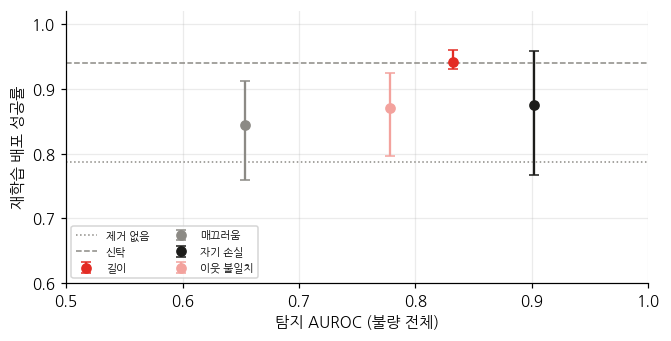

In [13]:
def rank(v):
    return np.argsort(np.argsort(v)).astype(float)


ks = list(METRIC)
a = np.array([AUC[k][0] for k in ks])
d = np.array([np.mean(DOWN[k]) for k in ks])
rho = np.corrcoef(rank(a), rank(d))[0, 1]
print(f"AUROC 순위와 배포 성공 순위의 스피어만 ρ = {rho:+.2f}")
print("  AUROC 순   : " + " > ".join(np.array(ks)[np.argsort(-a)]))
print("  배포 성공 순: " + " > ".join(np.array(ks)[np.argsort(-d)]))

fig, ax = plt.subplots(figsize=(6.2, 3.2))
for k, col in zip(ks, (RED, GREY, INK, PINK)):
    v = DOWN[k]
    ax.errorbar(AUC[k][0], np.mean(v),
                yerr=[[np.mean(v) - min(v)], [max(v) - np.mean(v)]],
                fmt="o", color=col, capsize=3, label=k)
for k, ls in (("제거 없음", ":"), ("신탁", "--")):
    ax.axhline(np.mean(DOWN[k]), color=GREY, ls=ls, lw=1, label=k)
ax.set_xlabel("탐지 AUROC (불량 전체)")
ax.set_ylabel("재학습 배포 성공률")
ax.set_xlim(.5, 1.)
ax.set_ylim(.6, 1.02)
ax.legend(fontsize=7, loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

## 불량 종류별 피해

왜 두 순위가 어긋나는지 보려면 **어느 불량이 성적을 떨어뜨리는지**부터 알아야 한다. 좋은 판 128개에 불량 한 종류씩만 섞어 학습한다.

In [14]:
GOOD = [e for e in EPS if e["type"] == "좋음"]
HARM = {}
t0 = time.time()
for t in TYPES[1:]:
    HARM[t], r = retrain(GOOD + [e for e in EPS if e["type"] == t],
                         f"harm-{t}")
    LOG += r
print(f"({time.time() - t0:.0f}s)\n")
print(pad("섞은 불량", 12) + pad("배포 성공", 11, True)
      + pad("범위", 15, True))
for k, v in [("없음 (신탁)", DOWN["신탁"])] + list(HARM.items()):
    print(pad(k, 12) + pad(f"{np.mean(v):.3f}", 11, True)
          + pad(f"[{min(v):.2f}, {max(v):.2f}]", 15, True))

(85s)

섞은 불량     배포 성공           범위
없음 (신탁)       0.940   [0.92, 0.98]
칸 착오           0.829   [0.67, 0.92]
망설임            0.947   [0.94, 0.96]
떨림              0.951   [0.93, 0.97]


## 골라낸 데이터를 남긴다

고르는 규칙을 코드로 적는다. **재학습 배포 성공률이 가장 높은 지표**를 쓴다. 탐지 AUROC 로 고르지 않는다. 남긴 판은 판 경계와 함께 저장한다 — 6장이 이 파일을 판 단위 형식으로 옮긴다.

In [15]:
best = max(METRIC, key=lambda k: np.mean(DOWN[k]))
keep = KEEP[best]
E = [EPS[i] for i in keep]
X, Y = cat(E)
lens = np.array([len(e["O"]) for e in E])
os.makedirs("data", exist_ok=True)
np.savez_compressed("data/clean_v1.npz", X=X, Y=Y, lengths=lens,
                    kind=np.array([e["kind"] for e in E]),
                    source=np.array([e["type"] for e in E]))
REP = {"metric": best, "kept": len(E), "dropped": len(EPS) - len(E),
       "bad_left": int(sum(e["type"] != "좋음" for e in E)),
       "auroc": {k: round(float(AUC[k][0]), 3) for k in METRIC},
       "auroc_len_ctrl": {k: round(float(auroc(BAD, TRS[k])), 3)
                          for k in METRIC},
       "deploy": {k: round(float(np.mean(v)), 3)
                  for k, v in DOWN.items()},
       "spearman": round(float(rho), 2)}
os.makedirs("report", exist_ok=True)
with open("report/curation.json", "w") as f:
    json.dump(REP, f, ensure_ascii=False, indent=1)
save_log("report/ch05_log.csv", LOG)
print(f"고른 지표 : {best}")
print(f"남긴 판   : {len(E)}  (남은 불량 {REP['bad_left']})")
print()
print("남긴 산출물")
print(f"  data/clean_v1.npz     {len(X):,} 스텝, 판 {len(E)}개")
print("  report/curation.json  지표별 AUROC·재학습 성적")
print(f"  report/ch05_log.csv   판별 로그 {len(LOG):,}줄")

고른 지표 : 길이
남긴 판   : 128  (남은 불량 10)

남긴 산출물
  data/clean_v1.npz     5,792 스텝, 판 128개
  report/curation.json  지표별 AUROC·재학습 성적
  report/ch05_log.csv   판별 로그 9,756줄


## 정리

**탐지 성능과 다운스트림 성적은 1위에서 갈렸다.** AUROC 1위 자기 손실(0.902)은 재학습 0.876, AUROC 2위 길이(0.832)는 재학습 0.942로 신탁과 같았다.

**이유는 피해의 분포다.** 세 불량 가운데 성적을 떨어뜨린 것은 칸 착오뿐이다(0.829). 망설임과 떨림은 섞어도 성적이 그대로다. 탐지 AUROC 는 해롭지 않은 불량을 잡는 데에도 점수를 준다.

**길이 지표의 승리는 교란 변수 덕분이다.** 칸 착오가 모두 110스텝이라 길이가 잡았을 뿐이고, 판 길이를 맞추면 AUROC 가 0.550으로 떨어진다. 실패한 시연이 시간을 채우는 과제에서만 통하는 지표다.

**그래서 지표는 재학습 성적으로 고른다.** 이 노트북은 길이를 골랐고, 남긴 128판에는 길이가 빼지 못한 불량 10판이 남아 있다. 모두 해롭지 않은 종류다. 그것을 `data/clean_v1.npz` 에 판 경계와 함께 적었다. 6장이 이 파일을 판 단위 형식으로 옮긴다.